# **LSTM**

In [ ]:
import shutil

shutil.rmtree('/content/drive', ignore_errors=True)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import joblib
import copy
import pandas as pd

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# PATHS
# -------------------------
BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

DATA_PATH = BASE_DIR / "New_data_scaled" / "scaled_chrono.npz"
Y_SCALER_PATH = BASE_DIR / "New_data_scaled" / "y_scaler.pkl"

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RESULT_DIR = BASE_DIR / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# -------------------------
# LOAD DATA
# -------------------------
data = np.load(DATA_PATH, allow_pickle=True)

X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]

y_test_true = data["y_test_true"]
p_last_test = data["p_last_test"]

y_scaler = joblib.load(Y_SCALER_PATH)

print("Shapes:", X_train.shape, y_train.shape)

# -------------------------
# DATASET
# -------------------------
class DatasetTS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

# -------------------------
# DATALOADERS
# -------------------------
train_loader = DataLoader(DatasetTS(X_train, y_train), batch_size=256, shuffle=False)
val_loader   = DataLoader(DatasetTS(X_val, y_val),   batch_size=256, shuffle=False)
test_loader  = DataLoader(DatasetTS(X_test, y_test), batch_size=256, shuffle=False)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Shapes: (44393, 360, 9) (44393, 5)


In [ ]:
# -------------------------
# MODEL
# -------------------------
class StrongLSTM(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=3,
            batch_first=True,
            dropout=0.1
        )

        self.head = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.head(out)

model = StrongLSTM(X_train.shape[2], y_train.shape[1]).to(device)

# -------------------------
# LOSS + OPTIMIZER
# -------------------------
weights = torch.tensor([1.0, 1.1, 1.3, 1.6, 2.0], device=device)

def loss_fn(pred, target):
    return torch.mean(weights * (pred - target) ** 2)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [ ]:
# -------------------------
# TRAINING
# -------------------------
EPOCHS = 60
PATIENCE = 15

best_val = float("inf")
best_state = None
wait = 0

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)

        loss = loss_fn(pred, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += loss_fn(pred, yb).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.5f} | Val: {val_loss:.5f}")

    # EARLY STOPPING
    if val_loss < best_val:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping triggered")
            break

# -------------------------
# LOAD BEST MODEL
# -------------------------
model.load_state_dict(best_state)
model.eval()

# -------------------------
# SAVE MODEL
# -------------------------
torch.save(model.state_dict(), MODEL_DIR / "lstm_model.pth")

Epoch 01 | Train: 1.33955 | Val: 1.56090
Epoch 02 | Train: 0.93311 | Val: 1.11885
Epoch 03 | Train: 0.70992 | Val: 1.16500
Epoch 04 | Train: 0.65456 | Val: 1.13747
Epoch 05 | Train: 0.65099 | Val: 1.13311
Epoch 06 | Train: 0.63688 | Val: 1.16077
Epoch 07 | Train: 0.66964 | Val: 1.20592
Epoch 08 | Train: 0.61743 | Val: 1.20346
Epoch 09 | Train: 0.60657 | Val: 1.19805
Epoch 10 | Train: 0.59689 | Val: 1.19435
Epoch 11 | Train: 0.61299 | Val: 1.30965
Epoch 12 | Train: 0.57854 | Val: 1.30789
Epoch 13 | Train: 0.57228 | Val: 1.29715
Epoch 14 | Train: 0.56749 | Val: 1.29735
Epoch 15 | Train: 0.57695 | Val: 1.40616
Epoch 16 | Train: 0.56211 | Val: 1.40610
Epoch 17 | Train: 0.55754 | Val: 1.40101
Early stopping triggered


In [ ]:
# -------------------------
# TEST PREDICTION
# -------------------------
preds = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds.append(model(xb).cpu().numpy())

y_pred_scaled = np.vstack(preds)

# ---- inverse scaling ----
y_pred_delta = y_scaler.inverse_transform(y_pred_scaled)

# ---- absolute ----
y_pred_abs = p_last_test[:, None] + y_pred_delta
y_test_abs = y_test_true

# -------------------------
# METRICS (UPDATED)
# -------------------------
labels = ["1h", "3h", "6h", "12h", "24h"]

print("\n===== FINAL LSTM RESULTS =====")

results = []

for i, h in enumerate(labels):
    y_t = y_test_abs[:, i]
    y_p = y_pred_abs[:, i]

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / np.maximum(y_t, 1e-6))) * 100

    print(f"{h} → MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f} | MAPE: {mape:.2f}%")

    results.append([h, mae, rmse, r2, mape])


===== FINAL LSTM RESULTS =====
1h → MAE: 6.612 | RMSE: 9.609 | R2: 0.496 | MAPE: 0.91%
3h → MAE: 14.465 | RMSE: 18.187 | R2: -0.871 | MAPE: 2.00%
6h → MAE: 20.213 | RMSE: 23.737 | R2: -2.295 | MAPE: 2.79%
12h → MAE: 15.417 | RMSE: 18.475 | R2: -0.917 | MAPE: 2.13%
24h → MAE: 17.586 | RMSE: 22.303 | R2: -2.685 | MAPE: 2.41%


In [ ]:
# -------------------------
# SAVE RESULTS
# -------------------------
df = pd.DataFrame(results, columns=["Horizon", "MAE", "RMSE", "R2", "MAPE (%)"])
df.to_csv(RESULT_DIR / "lstm_results.csv", index=False)

print("\nResults saved  lstm_results.csv")


Results saved  lstm_results.csv


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------
# LABELS
# -------------------------
labels = ["1h", "3h", "6h", "12h", "24h"]

mae_vals = []
rmse_vals = []

# -------------------------
# COMPUTE METRICS
# -------------------------
for i in range(len(labels)):
    mae = mean_absolute_error(y_test_abs[:, i], y_pred_abs[:, i])
    rmse = np.sqrt(mean_squared_error(y_test_abs[:, i], y_pred_abs[:, i]))

    mae_vals.append(mae)
    rmse_vals.append(rmse)

# -------------------------
# CREATE DATAFRAME
# -------------------------
df_metrics = pd.DataFrame({
    "Horizon": labels,
    "MAE": mae_vals,
    "RMSE": rmse_vals
})

print(df_metrics)

# -------------------------
# SAVE METRICS
# -------------------------
SAVE_PATH = Path("/content/drive/MyDrive/NASA_MEDA/results")
SAVE_PATH.mkdir(exist_ok=True)

csv_path = SAVE_PATH / "lstm_metrics.csv"
df_metrics.to_csv(csv_path, index=False)

print(f" Metrics saved at: {csv_path}")

  Horizon        MAE       RMSE
0      1h   6.611848   9.609391
1      3h  14.465143  18.186548
2      6h  20.213184  23.737196
3     12h  15.416515  18.475177
4     24h  17.586256  22.302814
 Metrics saved at: /content/drive/MyDrive/NASA_MEDA/results/lstm_metrics.csv


 Plot saved at: /content/drive/MyDrive/NASA_MEDA/results/lstm_error_vs_horizon.png


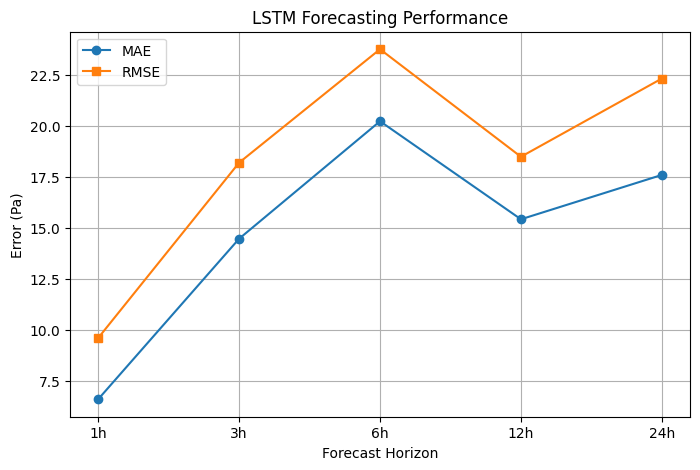

In [ ]:
# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(8,5))

plt.plot(labels, mae_vals, marker='o', label="MAE")
plt.plot(labels, rmse_vals, marker='s', label="RMSE")

plt.xlabel("Forecast Horizon")
plt.ylabel("Error (Pa)")
plt.title("LSTM Forecasting Performance")
plt.legend()
plt.grid()

# -------------------------
# SAVE PLOT
# -------------------------
plot_path = SAVE_PATH / "lstm_error_vs_horizon.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

print(f" Plot saved at: {plot_path}")

plt.show()

# **Transformer**

In [ ]:
# =========================
# STEP 8 — TRANSFORMER
# =========================

# -------------------------
# MOUNT DRIVE
# -------------------------
from google.colab import drive
drive.mount('/content/drive')

# -------------------------
# IMPORTS
# -------------------------
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import joblib
import copy
import random

# -------------------------
# REPRODUCIBILITY
# -------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
# -------------------------
# PATHS
# -------------------------
BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

DATA_PATH = BASE_DIR / "New_data_scaled" / "scaled_chrono.npz"
Y_SCALER_PATH = BASE_DIR / "New_data_scaled" / "y_scaler.pkl"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
data = np.load(DATA_PATH, allow_pickle=True)
y_scaler = joblib.load(Y_SCALER_PATH)

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]

y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

y_test_true = data["y_test_true"]
p_last_test = data["p_last_test"]

print("Shapes:", X_train.shape, y_train.shape)

# =========================
# DATASET
# =========================
class DatasetTS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(DatasetTS(X_train, y_train), batch_size=128, shuffle=False)
val_loader   = DataLoader(DatasetTS(X_val, y_val), batch_size=128, shuffle=False)
test_loader  = DataLoader(DatasetTS(X_test, y_test), batch_size=128, shuffle=False)

# =========================
# POSITIONAL ENCODING
# =========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Shapes: (44393, 360, 9) (44393, 5)


In [ ]:
# =========================
# MODEL
# =========================
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, 64)
        self.pos_enc = PositionalEncoding(64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.2,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.head = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.head(x)

model = TimeSeriesTransformer(
    input_dim=X_train.shape[2],
    output_dim=y_train.shape[1]
).to(device)

# =========================
# LOSS
# =========================
weights = torch.tensor([1.0, 1.2, 1.5, 2.0, 2.5], device=device)

def weighted_mse(pred, target):
    loss = (pred - target) ** 2
    loss = loss * weights
    return loss.mean()

# =========================
# OPTIMIZER
# =========================
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [ ]:
# =========================
# TRAINING
# =========================
EPOCHS = 60
PATIENCE = 12

best_val = np.inf
best_state = None
wait = 0

# HISTORY TRACKING
history = {
    "train_loss": [],
    "val_loss": [],
    "lr": []
}

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = weighted_mse(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += weighted_mse(pred, yb).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.5f} | Val: {val_loss:.5f} | LR: {current_lr:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping")
            break

# -------------------------
# LOAD BEST MODEL
# -------------------------
model.load_state_dict(best_state)
model.eval()

# -------------------------
# SAVE MODEL ONLY (NEW)
# -------------------------
MODEL_PATH = MODEL_DIR / "transformer_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": X_train.shape[2],
    "output_dim": y_train.shape[1],
    "d_model": 64,
    "nhead": 4,
    "dim_feedforward": 128,
    "num_layers": 2,
    "dropout": 0.2
}, MODEL_PATH)

print("Model saved to:", MODEL_PATH)

# =========================
# PREDICTION
# =========================
model.eval()
preds = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds.append(model(xb).cpu().numpy())

y_pred_scaled = np.vstack(preds)

# -------------------------
# INVERSE SCALE
# -------------------------
y_pred_delta = y_scaler.inverse_transform(y_pred_scaled)

# -------------------------
# DELTA → ABSOLUTE
# -------------------------
y_pred_abs = p_last_test[:, None] + y_pred_delta
y_test_abs = y_test_true

# =========================
# SAVE RESULTS
# =========================
RESULTS_PATH = BASE_DIR / "transformer_results.npz"

np.savez(
    RESULTS_PATH,
    train_loss=np.array(history["train_loss"]),
    val_loss=np.array(history["val_loss"]),
    lr=np.array(history["lr"]),
    y_pred_abs=y_pred_abs,
    y_test_abs=y_test_abs,
    best_val_loss=best_val
)

print("\nSaved results to:", RESULTS_PATH)

# =========================
# RESULTS
# =========================
labels = ["1h", "3h", "6h", "12h", "24h"]

print("\n===== FINAL TRANSFORMER RESULTS =====")

for i, h in enumerate(labels):
    mae = mean_absolute_error(y_test_abs[:, i], y_pred_abs[:, i])
    rmse = np.sqrt(mean_squared_error(y_test_abs[:, i], y_pred_abs[:, i]))
    print(f"{h} → MAE: {mae:.3f} | RMSE: {rmse:.3f}")

import matplotlib.pyplot as plt

data = np.load(RESULTS_PATH)

train_loss = data["train_loss"]
val_loss = data["val_loss"]

Epoch 01 | Train: 1.21564 | Val: 1.24733 | LR: 0.000100
Epoch 02 | Train: 0.77671 | Val: 1.13563 | LR: 0.000100
Epoch 03 | Train: 0.68141 | Val: 1.11408 | LR: 0.000100
Epoch 04 | Train: 0.65169 | Val: 1.09904 | LR: 0.000100
Epoch 05 | Train: 0.62905 | Val: 1.07142 | LR: 0.000100
Epoch 06 | Train: 0.61189 | Val: 1.05481 | LR: 0.000100
Epoch 07 | Train: 0.59435 | Val: 1.03588 | LR: 0.000100
Epoch 08 | Train: 0.58161 | Val: 1.01980 | LR: 0.000100
Epoch 09 | Train: 0.56689 | Val: 0.99616 | LR: 0.000100
Epoch 10 | Train: 0.55547 | Val: 0.98823 | LR: 0.000100
Epoch 11 | Train: 0.54443 | Val: 0.98233 | LR: 0.000100
Epoch 12 | Train: 0.53131 | Val: 0.97662 | LR: 0.000100
Epoch 13 | Train: 0.52359 | Val: 0.96588 | LR: 0.000100
Epoch 14 | Train: 0.51213 | Val: 0.96599 | LR: 0.000100
Epoch 15 | Train: 0.50404 | Val: 0.97042 | LR: 0.000100
Epoch 16 | Train: 0.49391 | Val: 0.97152 | LR: 0.000100
Epoch 17 | Train: 0.48785 | Val: 0.97240 | LR: 0.000050
Epoch 18 | Train: 0.50687 | Val: 0.92267 | LR: 0

Plot saved to: /content/drive/MyDrive/NASA_MEDA/transformer_training_curve.png


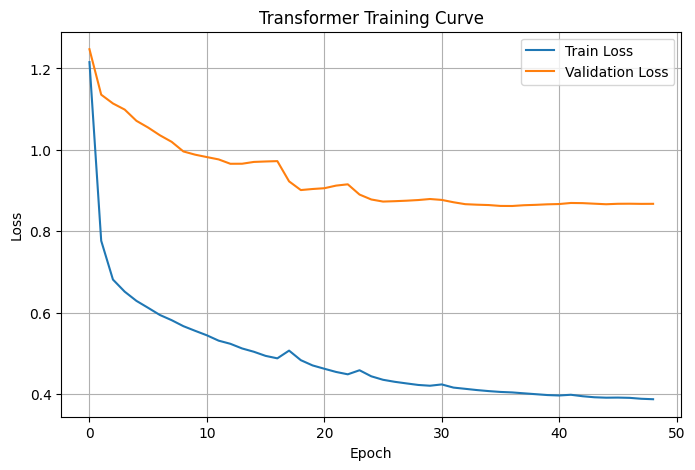

In [ ]:
# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training Curve")
plt.legend()
plt.grid()

# Save
PLOT_PATH = BASE_DIR / "transformer_training_curve.png"
plt.savefig(PLOT_PATH, dpi=300)

print("Plot saved to:", PLOT_PATH)

plt.show()

In [ ]:
# =========================
# LOAD NPZ + FULL METRICS
# =========================
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")
RESULTS_PATH = BASE_DIR / "transformer_results.npz"

data = np.load(RESULTS_PATH)

y_test_abs = data["y_test_abs"]
y_pred_abs = data["y_pred_abs"]

labels = ["1h", "3h", "6h", "12h", "24h"]

print("\n===== FULL TRANSFORMER METRICS =====")

results = []

for i, h in enumerate(labels):
    y_t = y_test_abs[:, i]
    y_p = y_pred_abs[:, i]

    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)
    mape = np.mean(np.abs((y_t - y_p) / np.maximum(y_t, 1e-6))) * 100

    print(f"{h} → MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f} | MAPE: {mape:.2f}%")

    results.append([h, mae, rmse, r2, mape])

# -------------------------
# SAVE CSV
# -------------------------
df = pd.DataFrame(results, columns=["Horizon", "MAE", "RMSE", "R2", "MAPE (%)"])

CSV_PATH = BASE_DIR / "transformer_full_metrics.csv"
df.to_csv(CSV_PATH, index=False)

print("\nSaved full metrics →", CSV_PATH)


===== FULL TRANSFORMER METRICS =====
1h → MAE: 6.343 | RMSE: 9.124 | R2: 0.546 | MAPE: 0.87%
3h → MAE: 12.788 | RMSE: 16.387 | R2: -0.519 | MAPE: 1.76%
6h → MAE: 12.417 | RMSE: 15.186 | R2: -0.349 | MAPE: 1.72%
12h → MAE: 13.345 | RMSE: 16.935 | R2: -0.611 | MAPE: 1.86%
24h → MAE: 12.336 | RMSE: 15.054 | R2: -0.679 | MAPE: 1.70%

Saved full metrics → /content/drive/MyDrive/NASA_MEDA/transformer_full_metrics.csv


# **Day vs Night : Experimet 01**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error

# =========================
# PATHS
# =========================
BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

BASELINE_PATH   = BASE_DIR / "New_data_scaled" / "baseline_predictions.npz"
TRANSFORMER_PATH = BASE_DIR / "transformer_results.npz"
DATA_PATH        = BASE_DIR / "New_data_scaled" / "scaled_chrono.npz"

# =========================
# LOAD DATA
# =========================
baseline = np.load(BASELINE_PATH)
transformer = np.load(TRANSFORMER_PATH)
data = np.load(DATA_PATH, allow_pickle=True)

# Predictions
y_test_abs = transformer["y_test_abs"]

y_pred_rf = baseline["y_pred_rf"]
y_pred_tr = transformer["y_pred_abs"]

In [ ]:
# =========================
# LOAD FILES
# =========================
baseline = np.load(BASELINE_PATH)
transformer = np.load(TRANSFORMER_PATH)
data = np.load(DATA_PATH, allow_pickle=True)

# =========================
# EXTRACT DATA
# =========================
X_test = data["X_test"]

y_test_abs = transformer["y_test_abs"]
y_pred_tr  = transformer["y_pred_abs"]
y_pred_rf = baseline["y_pred_rf"]


In [ ]:
# =========================
# FEATURE INDEX
# =========================
feature_names = [
    "ps_pressure",
    "rhs_local_relative_humidity",
    "rhs_humidity_local_temp",
    "sin_hour",
    "cos_hour",
    "sin_ls",
    "cos_ls",
    "is_day"
]

is_day_idx = feature_names.index("is_day")

In [ ]:
# =========================
# FIX SCALED BINARY FEATURE
# =========================
# Convert scaled is_day back to binary using threshold
is_day_test = X_test[:, -1, is_day_idx] > 0
is_night_test = ~is_day_test

print("Day samples:", is_day_test.sum())
print("Night samples:", is_night_test.sum())

# Optional sanity check
print("Day ratio:", is_day_test.mean())

Day samples: 2343
Night samples: 2100
Day ratio: 0.5273463875759622


In [ ]:
# =========================
# METRIC FUNCTION
# =========================
def compute_mae_split(y_true, y_pred, mask):
    return [
        mean_absolute_error(y_true[mask, i], y_pred[mask, i])
        for i in range(y_true.shape[1])
    ]

labels = ["1h", "3h", "6h", "12h", "24h"]

In [ ]:
# =========================
# COMPUTE METRICS
# =========================
rf_day   = compute_mae_split(y_test_abs, y_pred_rf, is_day_test)
rf_night = compute_mae_split(y_test_abs, y_pred_rf, is_night_test)

tr_day   = compute_mae_split(y_test_abs, y_pred_tr, is_day_test)
tr_night = compute_mae_split(y_test_abs, y_pred_tr, is_night_test)

In [ ]:
# =========================
# PRINT RESULTS
# =========================
print("\n===== DAY vs NIGHT MAE =====")

for i, h in enumerate(labels):
    print(
        f"{h} → "
        f"RF Day: {rf_day[i]:.2f} | RF Night: {rf_night[i]:.2f} | "
        f"TR Day: {tr_day[i]:.2f} | TR Night: {tr_night[i]:.2f}"
    )


===== DAY vs NIGHT MAE =====
1h → RF Day: 4.64 | RF Night: 6.27 | TR Day: 6.39 | TR Night: 6.30
3h → RF Day: 9.58 | RF Night: 8.85 | TR Day: 14.82 | TR Night: 10.52
6h → RF Day: 11.63 | RF Night: 12.92 | TR Day: 14.49 | TR Night: 10.10
12h → RF Day: 11.64 | RF Night: 12.07 | TR Day: 12.53 | TR Night: 14.26
24h → RF Day: 10.05 | RF Night: 15.33 | TR Day: 13.23 | TR Night: 11.34


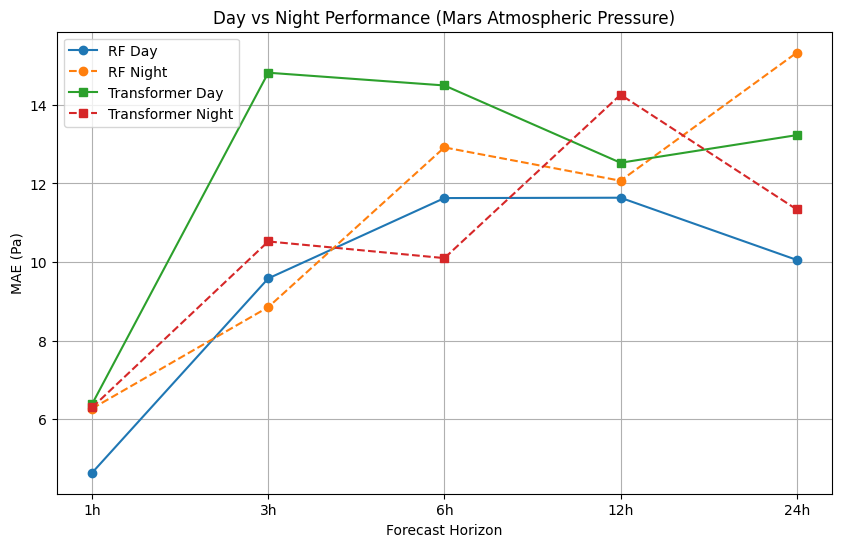

In [ ]:
# =========================
# PLOT
# =========================
x = np.arange(len(labels))

plt.figure(figsize=(10,6))

# Random Forest
plt.plot(x, rf_day, marker='o', linestyle='-', label="RF Day")
plt.plot(x, rf_night, marker='o', linestyle='--', label="RF Night")

# Transformer
plt.plot(x, tr_day, marker='s', linestyle='-', label="Transformer Day")
plt.plot(x, tr_night, marker='s', linestyle='--', label="Transformer Night")

plt.xticks(x, labels)
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE (Pa)")
plt.title("Day vs Night Performance (Mars Atmospheric Pressure)")
plt.legend()
plt.grid()

In [ ]:
# =========================
# STEP — TRANSFORMER (QUANTILE VERSION + MC DROPOUT + RESIDUAL CALIBRATION)
# =========================

# -------------------------
# IMPORTS
# -------------------------
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import joblib
import copy
import random

# -------------------------
# REPRODUCIBILITY
# -------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# -------------------------
# PATHS
# -------------------------
BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

DATA_PATH = BASE_DIR / "New_data_scaled" / "scaled_chrono.npz"
Y_SCALER_PATH = BASE_DIR / "New_data_scaled" / "y_scaler.pkl"
RESULTS_PATH = BASE_DIR / "transformer_quantile_mc_residual_calibrated_results.npz"

# -------------------------
# LOAD DATA
# -------------------------
data = np.load(DATA_PATH, allow_pickle=True)
y_scaler = joblib.load(Y_SCALER_PATH)

print("Available keys:", data.files)

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]

y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

y_test_true = data["y_test_true"]
p_last_test = data["p_last_test"]

# REQUIRED for residual calibration
if "p_last_val" not in data.files:
    raise KeyError(
        "p_last_val is missing in scaled_chrono.npz. "
        "You must save p_last_val during dataset/window creation."
    )

p_last_val = data["p_last_val"]

print("Shapes:", X_train.shape, y_train.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Available keys: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'y_train_true', 'y_val_true', 'y_test_true', 'p_last_train', 'p_last_val', 'p_last_test']
Shapes: (44393, 360, 9) (44393, 5)


In [ ]:
# =========================
# DATASET
# =========================
class DatasetTS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(DatasetTS(X_train, y_train), batch_size=128, shuffle=False)
val_loader   = DataLoader(DatasetTS(X_val, y_val), batch_size=128, shuffle=False)
test_loader  = DataLoader(DatasetTS(X_test, y_test), batch_size=128, shuffle=False)

In [ ]:
# =========================
# POSITIONAL ENCODING
# =========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

In [ ]:
# =========================
# MODEL
# =========================
HORIZONS = y_train.shape[1]
N_QUANTILES = 3
quantiles = [0.05, 0.5, 0.95]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, 64)
        self.pos_enc = PositionalEncoding(64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.2,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.head = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, HORIZONS * N_QUANTILES)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.head(x)

model = TimeSeriesTransformer(X_train.shape[2]).to(device)

In [ ]:
# =========================
# QUANTILE LOSS
# =========================
def quantile_loss(pred, target):
    pred = pred.view(-1, HORIZONS, len(quantiles))
    losses = []

    for i, q in enumerate(quantiles):
        errors = target - pred[:, :, i]
        loss = torch.max((q - 1) * errors, q * errors)
        losses.append(loss.unsqueeze(-1))

    return torch.cat(losses, dim=-1).mean()

# =========================
# OPTIMIZER
# =========================
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [ ]:
# =========================
# TRAINING
# =========================
EPOCHS = 60
PATIENCE = 12

best_val = np.inf
best_state = None
wait = 0

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = quantile_loss(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += quantile_loss(pred, yb).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.5f} | Val: {val_loss:.5f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping")
            break

# -------------------------
# LOAD BEST MODEL
# -------------------------
model.load_state_dict(best_state)

# =========================
# MC DROPOUT PREDICTION HELPER
# =========================
def mc_dropout_predict(loader, mc_passes=30):
    model.train()  # keep dropout ON
    preds_mc = []

    with torch.no_grad():
        for _ in range(mc_passes):
            batch_preds = []

            for xb, _ in loader:
                xb = xb.to(device)
                pred = model(xb).cpu().numpy()
                batch_preds.append(pred)

            batch_preds = np.vstack(batch_preds)
            preds_mc.append(batch_preds)

    preds_mc = np.stack(preds_mc, axis=0)      # [MC, N, HORIZONS * N_QUANTILES]
    mean_preds = preds_mc.mean(axis=0)         # [N, HORIZONS * N_QUANTILES]

    return mean_preds.reshape(-1, HORIZONS, len(quantiles))

# =========================
# TEST PREDICTION (RAW)
# =========================
y_test_pred_scaled = mc_dropout_predict(test_loader, mc_passes=30)

y_test_pred_delta = np.zeros_like(y_test_pred_scaled)

for i in range(len(quantiles)):
    y_test_pred_delta[:, :, i] = y_scaler.inverse_transform(
        y_test_pred_scaled[:, :, i]
    )

y_test_pred_abs = p_last_test[:, None, None] + y_test_pred_delta
y_test_pred_abs = np.sort(y_test_pred_abs, axis=2)

y_test_abs = y_test_true

# =========================
# VALIDATION PREDICTION FOR RESIDUAL CALIBRATION
# =========================
y_val_pred_scaled = mc_dropout_predict(val_loader, mc_passes=30)

y_val_pred_delta = np.zeros_like(y_val_pred_scaled)

for i in range(len(quantiles)):
    y_val_pred_delta[:, :, i] = y_scaler.inverse_transform(
        y_val_pred_scaled[:, :, i]
    )

y_val_pred_abs = p_last_val[:, None, None] + y_val_pred_delta
y_val_pred_abs = np.sort(y_val_pred_abs, axis=2)

# =========================
# TRUE VALIDATION ABSOLUTE VALUES (CORRECTED)
# =========================
y_val_abs = p_last_val[:, None] + y_scaler.inverse_transform(y_val)

# =========================
# METRIC FUNCTIONS
# =========================
def coverage(y_true, lower, upper):
    return np.mean((y_true >= lower) & (y_true <= upper))

def sharpness(lower, upper):
    return np.mean(upper - lower)

labels = ["1h", "3h", "6h", "12h", "24h"]

# =========================
# RAW UNCERTAINTY METRICS
# =========================
print("\n===== RAW UNCERTAINTY METRICS =====")

coverage_raw = []
sharpness_raw = []
median_mae_raw = []

for i, h in enumerate(labels):
    lower = y_test_pred_abs[:, i, 0]
    median = y_test_pred_abs[:, i, 1]
    upper = y_test_pred_abs[:, i, 2]

    cov = coverage(y_test_abs[:, i], lower, upper)
    width = sharpness(lower, upper)
    mae_median = np.mean(np.abs(y_test_abs[:, i] - median))

    coverage_raw.append(cov)
    sharpness_raw.append(width)
    median_mae_raw.append(mae_median)

    print(f"{h} → Coverage: {cov:.3f} | Width: {width:.2f} | Median MAE: {mae_median:.2f}")

# =========================
# RESIDUAL-BASED CALIBRATION
# =========================
val_median = y_val_pred_abs[:, :, 1]
val_residuals = np.abs(y_val_abs - val_median)

# 90% residual quantile per horizon
res_q = np.quantile(val_residuals, 0.90, axis=0)

print("\nResidual quantiles (per horizon):", np.round(res_q, 2))

# Apply calibration to test
test_median = y_test_pred_abs[:, :, 1]
y_test_low_cal = test_median - res_q[None, :]
y_test_hi_cal  = test_median + res_q[None, :]

# =========================
# CALIBRATED METRICS
# =========================
print("\n===== RESIDUAL-CALIBRATED METRICS =====")

coverage_cal = []
sharpness_cal = []
median_mae_cal = []

for i, h in enumerate(labels):
    cov = coverage(y_test_abs[:, i], y_test_low_cal[:, i], y_test_hi_cal[:, i])
    width = sharpness(y_test_low_cal[:, i], y_test_hi_cal[:, i])
    mae_median = np.mean(np.abs(y_test_abs[:, i] - test_median[:, i]))

    coverage_cal.append(cov)
    sharpness_cal.append(width)
    median_mae_cal.append(mae_median)

    print(f"{h} → Coverage: {cov:.3f} | Width: {width:.2f} | Median MAE: {mae_median:.2f}")

Epoch 01 | Train: 0.25105 | Val: 0.20448
Epoch 02 | Train: 0.16401 | Val: 0.17287
Epoch 03 | Train: 0.14409 | Val: 0.16538
Epoch 04 | Train: 0.13479 | Val: 0.16184
Epoch 05 | Train: 0.12955 | Val: 0.16075
Epoch 06 | Train: 0.12542 | Val: 0.15932
Epoch 07 | Train: 0.12168 | Val: 0.15631
Epoch 08 | Train: 0.11919 | Val: 0.15570
Epoch 09 | Train: 0.11662 | Val: 0.15470
Epoch 10 | Train: 0.11444 | Val: 0.15233
Epoch 11 | Train: 0.11269 | Val: 0.15066
Epoch 12 | Train: 0.11138 | Val: 0.14920
Epoch 13 | Train: 0.10973 | Val: 0.14791
Epoch 14 | Train: 0.10810 | Val: 0.14603
Epoch 15 | Train: 0.10667 | Val: 0.14501
Epoch 16 | Train: 0.10525 | Val: 0.14411
Epoch 17 | Train: 0.10409 | Val: 0.14258
Epoch 18 | Train: 0.10281 | Val: 0.14187
Epoch 19 | Train: 0.10164 | Val: 0.14141
Epoch 20 | Train: 0.10056 | Val: 0.14140
Epoch 21 | Train: 0.09953 | Val: 0.14064
Epoch 22 | Train: 0.09872 | Val: 0.14051
Epoch 23 | Train: 0.09787 | Val: 0.14024
Epoch 24 | Train: 0.09671 | Val: 0.13845
Epoch 25 | Train

In [ ]:
# =========================
# SAVE RESULTS
# =========================
np.savez(
    RESULTS_PATH,
    train_loss=np.array(history["train_loss"]),
    val_loss=np.array(history["val_loss"]),

    y_val_abs=y_val_abs,
    y_val_pred_abs=y_val_pred_abs,

    y_test_abs=y_test_abs,
    y_test_pred_abs=y_test_pred_abs,

    y_test_low_cal=y_test_low_cal,
    y_test_hi_cal=y_test_hi_cal,

    residual_quantiles=res_q,

    coverage_raw=np.array(coverage_raw),
    sharpness_raw=np.array(sharpness_raw),
    median_mae_raw=np.array(median_mae_raw),

    coverage_cal=np.array(coverage_cal),
    sharpness_cal=np.array(sharpness_cal),
    median_mae_cal=np.array(median_mae_cal),

    quantiles=np.array(quantiles),
    best_val_loss=best_val
)

print("\nSaved results to:", RESULTS_PATH)


Saved results to: /content/drive/MyDrive/NASA_MEDA/transformer_quantile_mc_residual_calibrated_results.npz


In [ ]:
# =========================
# STEP — TRANSFORMER + MC DROPOUT + CONFORMAL PREDICTION
# =========================

# -------------------------
# IMPORTS
# -------------------------
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import joblib
import copy
import random

# -------------------------
# REPRODUCIBILITY
# -------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# PATHS
# -------------------------
BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

DATA_PATH = BASE_DIR / "New_data_scaled" / "scaled_chrono.npz"
Y_SCALER_PATH = BASE_DIR / "New_data_scaled" / "y_scaler.pkl"
RESULTS_PATH = BASE_DIR / "transformer_conformal_results.npz"

# -------------------------
# LOAD DATA
# -------------------------
data = np.load(DATA_PATH, allow_pickle=True)
y_scaler = joblib.load(Y_SCALER_PATH)

print("Available keys:", data.files)

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]

y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

y_test_true = data["y_test_true"]
p_last_test = data["p_last_test"]

if "p_last_val" not in data.files:
    raise KeyError(
        "p_last_val is missing in scaled_chrono.npz. "
        "You must save p_last_val during dataset/window creation."
    )

p_last_val = data["p_last_val"]

print("Shapes:", X_train.shape, y_train.shape)

# =========================
# DATASET
# =========================
class DatasetTS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(DatasetTS(X_train, y_train), batch_size=128, shuffle=False)
val_loader   = DataLoader(DatasetTS(X_val, y_val), batch_size=128, shuffle=False)
test_loader  = DataLoader(DatasetTS(X_test, y_test), batch_size=128, shuffle=False)

Device: cuda
Available keys: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'y_train_true', 'y_val_true', 'y_test_true', 'p_last_train', 'p_last_val', 'p_last_test']


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Shapes: (44393, 360, 9) (44393, 5)


In [ ]:
# =========================
# POSITIONAL ENCODING
# =========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# =========================
# MODEL
# =========================
HORIZONS = y_train.shape[1]
N_QUANTILES = 3
quantiles = [0.05, 0.5, 0.95]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, 64)
        self.pos_enc = PositionalEncoding(64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.2,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.head = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, HORIZONS * N_QUANTILES)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.head(x)

model = TimeSeriesTransformer(X_train.shape[2]).to(device)

# =========================
# QUANTILE LOSS
# =========================
def quantile_loss(pred, target):
    pred = pred.view(-1, HORIZONS, len(quantiles))
    losses = []

    for i, q in enumerate(quantiles):
        errors = target - pred[:, :, i]
        loss = torch.max((q - 1) * errors, q * errors)
        losses.append(loss.unsqueeze(-1))

    return torch.cat(losses, dim=-1).mean()

# =========================
# OPTIMIZER
# =========================
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [ ]:
# =========================
# TRAINING
# =========================
EPOCHS = 60
PATIENCE = 12

best_val = np.inf
best_state = None
wait = 0

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = quantile_loss(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += quantile_loss(pred, yb).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.5f} | Val: {val_loss:.5f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping")
            break

model.load_state_dict(best_state)

# =========================
# MC DROPOUT HELPER
# =========================
def mc_dropout_predict(loader, mc_passes=30):
    model.train()  # keep dropout ON
    preds_mc = []

    with torch.no_grad():
        for _ in range(mc_passes):
            batch_preds = []

            for xb, _ in loader:
                xb = xb.to(device)
                pred = model(xb).cpu().numpy()
                batch_preds.append(pred)

            batch_preds = np.vstack(batch_preds)
            preds_mc.append(batch_preds)

    preds_mc = np.stack(preds_mc, axis=0)   # [MC, N, H*Q]
    mean_preds = preds_mc.mean(axis=0)      # [N, H*Q]
    return mean_preds.reshape(-1, HORIZONS, len(quantiles))

# =========================
# RAW TEST PREDICTIONS
# =========================
y_test_pred_scaled = mc_dropout_predict(test_loader, mc_passes=30)

y_test_pred_delta = np.zeros_like(y_test_pred_scaled)
for i in range(len(quantiles)):
    y_test_pred_delta[:, :, i] = y_scaler.inverse_transform(
        y_test_pred_scaled[:, :, i]
    )

y_test_pred_abs = p_last_test[:, None, None] + y_test_pred_delta
y_test_pred_abs = np.sort(y_test_pred_abs, axis=2)

y_test_abs = y_test_true

# =========================
# RAW VALIDATION PREDICTIONS
# =========================
y_val_pred_scaled = mc_dropout_predict(val_loader, mc_passes=30)

y_val_pred_delta = np.zeros_like(y_val_pred_scaled)
for i in range(len(quantiles)):
    y_val_pred_delta[:, :, i] = y_scaler.inverse_transform(
        y_val_pred_scaled[:, :, i]
    )

y_val_pred_abs = p_last_val[:, None, None] + y_val_pred_delta
y_val_pred_abs = np.sort(y_val_pred_abs, axis=2)

# True validation absolute
y_val_delta = y_scaler.inverse_transform(y_val)
y_val_abs = p_last_val[:, None] + y_val_delta

# =========================
# METRIC FUNCTIONS
# =========================
def coverage(y_true, lower, upper):
    return np.mean((y_true >= lower) & (y_true <= upper))

def sharpness(lower, upper):
    return np.mean(upper - lower)

labels = ["1h", "3h", "6h", "12h", "24h"]

# =========================
# RAW METRICS
# =========================
print("\n===== RAW UNCERTAINTY METRICS =====")

coverage_raw = []
sharpness_raw = []
median_mae_raw = []

for i, h in enumerate(labels):
    lower = y_test_pred_abs[:, i, 0]
    median = y_test_pred_abs[:, i, 1]
    upper = y_test_pred_abs[:, i, 2]

    cov = coverage(y_test_abs[:, i], lower, upper)
    width = sharpness(lower, upper)
    mae_median = np.mean(np.abs(y_test_abs[:, i] - median))

    coverage_raw.append(cov)
    sharpness_raw.append(width)
    median_mae_raw.append(mae_median)

    print(f"{h} → Coverage: {cov:.3f} | Width: {width:.2f} | Median MAE: {mae_median:.2f}")

# =========================
# CONFORMAL PREDICTION
# =========================
# Use validation residuals of the median predictor
val_median = y_val_pred_abs[:, :, 1]
val_abs_error = np.abs(y_val_abs - val_median)

# finite-sample conformal quantile
# target interval coverage = 90%
alpha = 0.10
n_val = val_abs_error.shape[0]

conformal_q = np.zeros(HORIZONS)

for h in range(HORIZONS):
    scores = np.sort(val_abs_error[:, h])

    # finite-sample corrected index
    k = int(np.ceil((n_val + 1) * (1 - alpha))) - 1
    k = min(max(k, 0), n_val - 1)

    conformal_q[h] = scores[k]

print("\nConformal radii (per horizon):", np.round(conformal_q, 2))

# Apply conformal intervals to test median
test_median = y_test_pred_abs[:, :, 1]
y_test_low_conf = test_median - conformal_q[None, :]
y_test_hi_conf  = test_median + conformal_q[None, :]

# =========================
# CONFORMAL METRICS
# =========================
print("\n===== CONFORMAL METRICS =====")

coverage_conf = []
sharpness_conf = []
median_mae_conf = []

for i, h in enumerate(labels):
    cov = coverage(y_test_abs[:, i], y_test_low_conf[:, i], y_test_hi_conf[:, i])
    width = sharpness(y_test_low_conf[:, i], y_test_hi_conf[:, i])
    mae_median = np.mean(np.abs(y_test_abs[:, i] - test_median[:, i]))

    coverage_conf.append(cov)
    sharpness_conf.append(width)
    median_mae_conf.append(mae_median)

    print(f"{h} → Coverage: {cov:.3f} | Width: {width:.2f} | Median MAE: {mae_median:.2f}")

# =========================
# SAVE RESULTS
# =========================
np.savez(
    RESULTS_PATH,
    train_loss=np.array(history["train_loss"]),
    val_loss=np.array(history["val_loss"]),

    y_val_abs=y_val_abs,
    y_val_pred_abs=y_val_pred_abs,

    y_test_abs=y_test_abs,
    y_test_pred_abs=y_test_pred_abs,

    y_test_low_conf=y_test_low_conf,
    y_test_hi_conf=y_test_hi_conf,

    conformal_radii=conformal_q,

    coverage_raw=np.array(coverage_raw),
    sharpness_raw=np.array(sharpness_raw),
    median_mae_raw=np.array(median_mae_raw),

    coverage_conf=np.array(coverage_conf),
    sharpness_conf=np.array(sharpness_conf),
    median_mae_conf=np.array(median_mae_conf),

    quantiles=np.array(quantiles),
    alpha=alpha,
    best_val_loss=best_val
)

print("\nSaved results to:", RESULTS_PATH)

Epoch 01 | Train: 0.25105 | Val: 0.20448
Epoch 02 | Train: 0.16401 | Val: 0.17290
Epoch 03 | Train: 0.14409 | Val: 0.16537
Epoch 04 | Train: 0.13479 | Val: 0.16187
Epoch 05 | Train: 0.12957 | Val: 0.16079
Epoch 06 | Train: 0.12542 | Val: 0.15923
Epoch 07 | Train: 0.12170 | Val: 0.15635
Epoch 08 | Train: 0.11922 | Val: 0.15588
Epoch 09 | Train: 0.11658 | Val: 0.15487
Epoch 10 | Train: 0.11441 | Val: 0.15246
Epoch 11 | Train: 0.11267 | Val: 0.15093
Epoch 12 | Train: 0.11134 | Val: 0.14939
Epoch 13 | Train: 0.10970 | Val: 0.14791
Epoch 14 | Train: 0.10813 | Val: 0.14617
Epoch 15 | Train: 0.10667 | Val: 0.14514
Epoch 16 | Train: 0.10528 | Val: 0.14408
Epoch 17 | Train: 0.10411 | Val: 0.14261
Epoch 18 | Train: 0.10282 | Val: 0.14177
Epoch 19 | Train: 0.10168 | Val: 0.14139
Epoch 20 | Train: 0.10055 | Val: 0.14145
Epoch 21 | Train: 0.09953 | Val: 0.14069
Epoch 22 | Train: 0.09873 | Val: 0.14032
Epoch 23 | Train: 0.09790 | Val: 0.14016
Epoch 24 | Train: 0.09670 | Val: 0.13856
Epoch 25 | Train

# **day/night conformal prediction**

In [ ]:
# =========================
# STEP — TRANSFORMER + MC DROPOUT + DAY/NIGHT CONFORMAL
# =========================

# -------------------------
# IMPORTS
# -------------------------
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import joblib
import copy
import random

# -------------------------
# REPRODUCIBILITY
# -------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# PATHS
# -------------------------
BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

DATA_PATH = BASE_DIR / "New_data_scaled" / "scaled_chrono.npz"
Y_SCALER_PATH = BASE_DIR / "New_data_scaled" / "y_scaler.pkl"
RESULTS_PATH = BASE_DIR / "transformer_daynight_conformal_results.npz"

# -------------------------
# LOAD DATA
# -------------------------
data = np.load(DATA_PATH, allow_pickle=True)
y_scaler = joblib.load(Y_SCALER_PATH)

print("Available keys:", data.files)

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]

y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

y_test_true = data["y_test_true"]
p_last_test = data["p_last_test"]

if "p_last_val" not in data.files:
    raise KeyError(
        "p_last_val is missing in scaled_chrono.npz. "
        "You must save p_last_val during dataset/window creation."
    )

p_last_val = data["p_last_val"]

print("Shapes:", X_train.shape, y_train.shape)

Device: cuda
Available keys: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'y_train_true', 'y_val_true', 'y_test_true', 'p_last_train', 'p_last_val', 'p_last_test']


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Shapes: (44393, 360, 9) (44393, 5)


In [ ]:
# =========================
# FEATURE INDEX FOR is_day
# =========================
feature_names = [
    "ps_pressure",
    "rhs_local_relative_humidity",
    "rhs_humidity_local_temp",
    "sin_hour",
    "cos_hour",
    "sin_ls",
    "cos_ls",
    "is_day"
]

is_day_idx = feature_names.index("is_day")

# is_day was scaled, so convert using threshold > 0
is_day_val = X_val[:, -1, is_day_idx] > 0
is_day_test = X_test[:, -1, is_day_idx] > 0

is_night_val = ~is_day_val
is_night_test = ~is_day_test

print("Validation day/night:", is_day_val.sum(), is_night_val.sum())
print("Test day/night:", is_day_test.sum(), is_night_test.sum())

# =========================
# DATASET
# =========================
class DatasetTS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(DatasetTS(X_train, y_train), batch_size=128, shuffle=False)
val_loader   = DataLoader(DatasetTS(X_val, y_val), batch_size=128, shuffle=False)
test_loader  = DataLoader(DatasetTS(X_test, y_test), batch_size=128, shuffle=False)

Validation day/night: 4970 4809
Test day/night: 2343 2100


In [ ]:
# =========================
# POSITIONAL ENCODING
# =========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# =========================
# MODEL
# =========================
HORIZONS = y_train.shape[1]
N_QUANTILES = 3
quantiles = [0.05, 0.5, 0.95]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, 64)
        self.pos_enc = PositionalEncoding(64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.2,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.head = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, HORIZONS * N_QUANTILES)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.head(x)

model = TimeSeriesTransformer(X_train.shape[2]).to(device)

# =========================
# QUANTILE LOSS
# =========================
def quantile_loss(pred, target):
    pred = pred.view(-1, HORIZONS, len(quantiles))
    losses = []

    for i, q in enumerate(quantiles):
        errors = target - pred[:, :, i]
        loss = torch.max((q - 1) * errors, q * errors)
        losses.append(loss.unsqueeze(-1))

    return torch.cat(losses, dim=-1).mean()

# =========================
# OPTIMIZER
# =========================
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [ ]:
# =========================
# TRAINING
# =========================
EPOCHS = 60
PATIENCE = 12

best_val = np.inf
best_state = None
wait = 0

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = quantile_loss(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += quantile_loss(pred, yb).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.5f} | Val: {val_loss:.5f}")

    if val_loss < best_val:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping")
            break

model.load_state_dict(best_state)

# =========================
# MC DROPOUT HELPER
# =========================
def mc_dropout_predict(loader, mc_passes=30):
    model.train()
    preds_mc = []

    with torch.no_grad():
        for _ in range(mc_passes):
            batch_preds = []

            for xb, _ in loader:
                xb = xb.to(device)
                pred = model(xb).cpu().numpy()
                batch_preds.append(pred)

            batch_preds = np.vstack(batch_preds)
            preds_mc.append(batch_preds)

    preds_mc = np.stack(preds_mc, axis=0)
    mean_preds = preds_mc.mean(axis=0)
    return mean_preds.reshape(-1, HORIZONS, len(quantiles))

# =========================
# PREDICT VALIDATION + TEST
# =========================
y_val_pred_scaled = mc_dropout_predict(val_loader, mc_passes=30)
y_test_pred_scaled = mc_dropout_predict(test_loader, mc_passes=30)

# inverse transform predictions
y_val_pred_delta = np.zeros_like(y_val_pred_scaled)
y_test_pred_delta = np.zeros_like(y_test_pred_scaled)

for i in range(len(quantiles)):
    y_val_pred_delta[:, :, i] = y_scaler.inverse_transform(y_val_pred_scaled[:, :, i])
    y_test_pred_delta[:, :, i] = y_scaler.inverse_transform(y_test_pred_scaled[:, :, i])

# convert to absolute
y_val_pred_abs = p_last_val[:, None, None] + y_val_pred_delta
y_test_pred_abs = p_last_test[:, None, None] + y_test_pred_delta

y_val_pred_abs = np.sort(y_val_pred_abs, axis=2)
y_test_pred_abs = np.sort(y_test_pred_abs, axis=2)

# true validation absolute
y_val_delta = y_scaler.inverse_transform(y_val)
y_val_abs = p_last_val[:, None] + y_val_delta

# test truth
y_test_abs = y_test_true

# =========================
# METRIC FUNCTIONS
# =========================
def coverage(y_true, lower, upper):
    return np.mean((y_true >= lower) & (y_true <= upper))

def sharpness(lower, upper):
    return np.mean(upper - lower)

labels = ["1h", "3h", "6h", "12h", "24h"]

# =========================
# RAW METRICS
# =========================
print("\n===== RAW UNCERTAINTY METRICS =====")

coverage_raw = []
sharpness_raw = []
median_mae_raw = []

for i, h in enumerate(labels):
    lower = y_test_pred_abs[:, i, 0]
    median = y_test_pred_abs[:, i, 1]
    upper = y_test_pred_abs[:, i, 2]

    cov = coverage(y_test_abs[:, i], lower, upper)
    width = sharpness(lower, upper)
    mae_median = np.mean(np.abs(y_test_abs[:, i] - median))

    coverage_raw.append(cov)
    sharpness_raw.append(width)
    median_mae_raw.append(mae_median)

    print(f"{h} → Coverage: {cov:.3f} | Width: {width:.2f} | Median MAE: {mae_median:.2f}")

# =========================
# DAY/NIGHT CONFORMAL RADII
# =========================
alpha = 0.10

val_median = y_val_pred_abs[:, :, 1]
val_abs_error = np.abs(y_val_abs - val_median)

def conformal_radius(scores, alpha=0.10):
    n = len(scores)
    if n == 0:
        return np.nan
    scores = np.sort(scores)
    k = int(np.ceil((n + 1) * (1 - alpha))) - 1
    k = min(max(k, 0), n - 1)
    return scores[k]

q_day = np.zeros(HORIZONS)
q_night = np.zeros(HORIZONS)

for h in range(HORIZONS):
    q_day[h] = conformal_radius(val_abs_error[is_day_val, h], alpha=alpha)
    q_night[h] = conformal_radius(val_abs_error[is_night_val, h], alpha=alpha)

print("\nDay conformal radii:", np.round(q_day, 2))
print("Night conformal radii:", np.round(q_night, 2))

# =========================
# APPLY DAY/NIGHT CONFORMAL TO TEST
# =========================
test_median = y_test_pred_abs[:, :, 1]

y_test_low_dn = np.zeros_like(test_median)
y_test_hi_dn  = np.zeros_like(test_median)

for i in range(len(test_median)):
    if is_day_test[i]:
        y_test_low_dn[i, :] = test_median[i, :] - q_day
        y_test_hi_dn[i, :]  = test_median[i, :] + q_day
    else:
        y_test_low_dn[i, :] = test_median[i, :] - q_night
        y_test_hi_dn[i, :]  = test_median[i, :] + q_night

# =========================
# DAY/NIGHT CONFORMAL METRICS
# =========================
print("\n===== DAY/NIGHT CONFORMAL METRICS =====")

coverage_dn = []
sharpness_dn = []
median_mae_dn = []

for i, h in enumerate(labels):
    cov = coverage(y_test_abs[:, i], y_test_low_dn[:, i], y_test_hi_dn[:, i])
    width = sharpness(y_test_low_dn[:, i], y_test_hi_dn[:, i])
    mae_median = np.mean(np.abs(y_test_abs[:, i] - test_median[:, i]))

    coverage_dn.append(cov)
    sharpness_dn.append(width)
    median_mae_dn.append(mae_median)

    print(f"{h} → Coverage: {cov:.3f} | Width: {width:.2f} | Median MAE: {mae_median:.2f}")

# =========================
# OPTIONAL: REPORT DAY/NIGHT COVERAGE SEPARATELY
# =========================
print("\n===== DAY/NIGHT COVERAGE SEPARATELY =====")

for i, h in enumerate(labels):
    cov_day = coverage(
        y_test_abs[is_day_test, i],
        y_test_low_dn[is_day_test, i],
        y_test_hi_dn[is_day_test, i]
    )

    cov_night = coverage(
        y_test_abs[is_night_test, i],
        y_test_low_dn[is_night_test, i],
        y_test_hi_dn[is_night_test, i]
    )

    print(f"{h} → Day: {cov_day:.3f} | Night: {cov_night:.3f}")

Epoch 01 | Train: 0.25105 | Val: 0.20448
Epoch 02 | Train: 0.16401 | Val: 0.17287
Epoch 03 | Train: 0.14409 | Val: 0.16538
Epoch 04 | Train: 0.13479 | Val: 0.16185
Epoch 05 | Train: 0.12955 | Val: 0.16072
Epoch 06 | Train: 0.12544 | Val: 0.15917
Epoch 07 | Train: 0.12170 | Val: 0.15618
Epoch 08 | Train: 0.11920 | Val: 0.15554
Epoch 09 | Train: 0.11663 | Val: 0.15456
Epoch 10 | Train: 0.11444 | Val: 0.15222
Epoch 11 | Train: 0.11269 | Val: 0.15063
Epoch 12 | Train: 0.11135 | Val: 0.14920
Epoch 13 | Train: 0.10970 | Val: 0.14782
Epoch 14 | Train: 0.10810 | Val: 0.14585
Epoch 15 | Train: 0.10664 | Val: 0.14507
Epoch 16 | Train: 0.10528 | Val: 0.14397
Epoch 17 | Train: 0.10405 | Val: 0.14255
Epoch 18 | Train: 0.10282 | Val: 0.14197
Epoch 19 | Train: 0.10164 | Val: 0.14146
Epoch 20 | Train: 0.10055 | Val: 0.14145
Epoch 21 | Train: 0.09952 | Val: 0.14071
Epoch 22 | Train: 0.09872 | Val: 0.14043
Epoch 23 | Train: 0.09786 | Val: 0.14033
Epoch 24 | Train: 0.09670 | Val: 0.13852
Epoch 25 | Train

In [ ]:
# =========================
# SAVE RESULTS
# =========================
np.savez(
    RESULTS_PATH,
    train_loss=np.array(history["train_loss"]),
    val_loss=np.array(history["val_loss"]),

    y_val_abs=y_val_abs,
    y_val_pred_abs=y_val_pred_abs,

    y_test_abs=y_test_abs,
    y_test_pred_abs=y_test_pred_abs,

    y_test_low_dn=y_test_low_dn,
    y_test_hi_dn=y_test_hi_dn,

    q_day=q_day,
    q_night=q_night,

    is_day_val=is_day_val,
    is_day_test=is_day_test,

    coverage_raw=np.array(coverage_raw),
    sharpness_raw=np.array(sharpness_raw),
    median_mae_raw=np.array(median_mae_raw),

    coverage_dn=np.array(coverage_dn),
    sharpness_dn=np.array(sharpness_dn),
    median_mae_dn=np.array(median_mae_dn),

    quantiles=np.array(quantiles),
    alpha=alpha,
    best_val_loss=best_val
)

print("\nSaved results to:", RESULTS_PATH)


Saved results to: /content/drive/MyDrive/NASA_MEDA/transformer_daynight_conformal_results.npz


In [ ]:
# =========================
# STEP — CHECK AVAILABLE UNCERTAINTY DATA
# =========================

import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

# 🔧 Change file name if needed
FILE_PATH = BASE_DIR / "transformer_daynight_conformal_results.npz"

data = np.load(FILE_PATH, allow_pickle=True)

print("\n===== AVAILABLE KEYS =====")
for k in data.files:
    print(k)

print("\n===== SHAPE CHECK =====")
for k in data.files:
    try:
        print(f"{k}: {data[k].shape}")
    except:
        print(f"{k}: (not array)")


===== AVAILABLE KEYS =====
train_loss
val_loss
y_val_abs
y_val_pred_abs
y_test_abs
y_test_pred_abs
y_test_low_dn
y_test_hi_dn
q_day
q_night
is_day_val
is_day_test
coverage_raw
sharpness_raw
median_mae_raw
coverage_dn
sharpness_dn
median_mae_dn
quantiles
alpha
best_val_loss

===== SHAPE CHECK =====
train_loss: (60,)
val_loss: (60,)
y_val_abs: (9779, 5)
y_val_pred_abs: (9779, 5, 3)
y_test_abs: (4443, 5)
y_test_pred_abs: (4443, 5, 3)
y_test_low_dn: (4443, 5)
y_test_hi_dn: (4443, 5)
q_day: (5,)
q_night: (5,)
is_day_val: (9779,)
is_day_test: (4443,)
coverage_raw: (5,)
sharpness_raw: (5,)
median_mae_raw: (5,)
coverage_dn: (5,)
sharpness_dn: (5,)
median_mae_dn: (5,)
quantiles: (3,)
alpha: ()
best_val_loss: ()


In [ ]:
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")
data = np.load(BASE_DIR / "transformer_daynight_conformal_results.npz", allow_pickle=True)

y_true = data["y_test_abs"]             # (N, H)
y_pred = data["y_test_pred_abs"]        # (N, H, Q)
quantiles = data["quantiles"]           # (Q,)

print("Quantiles:", quantiles)

Quantiles: [0.05 0.5  0.95]


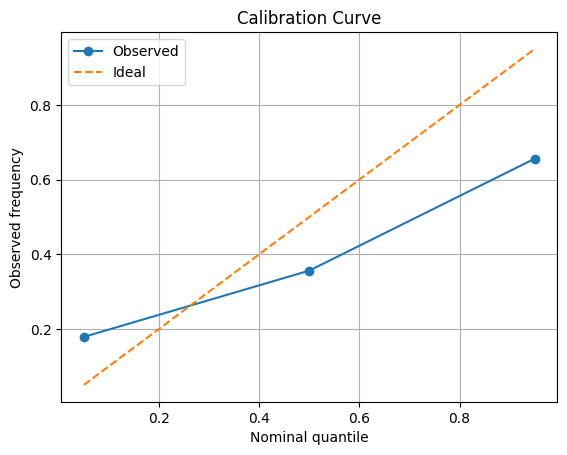

In [ ]:
import matplotlib.pyplot as plt

levels = []
observed = []

for q in quantiles:
    levels.append(q)

    # Check proportion where true <= predicted quantile
    mask = (y_true <= y_pred[:, :, list(quantiles).index(q)])
    observed.append(mask.mean())

plt.figure()
plt.plot(levels, observed, marker='o', label="Observed")
plt.plot(levels, levels, '--', label="Ideal")
plt.xlabel("Nominal quantile")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.legend()
plt.grid()
plt.show()

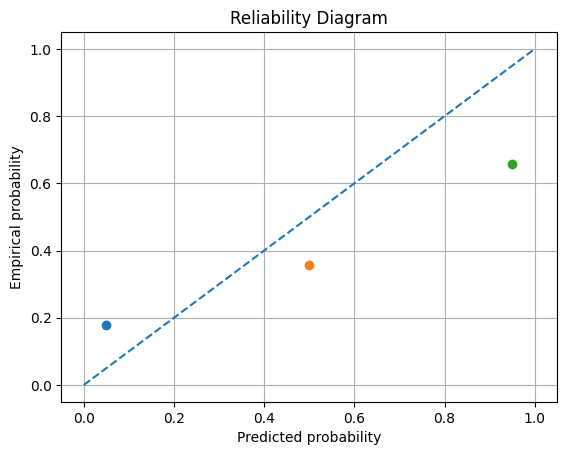

In [ ]:
plt.figure()

for i, q in enumerate(quantiles):
    coverage = (y_true <= y_pred[:, :, i]).mean()
    plt.scatter(q, coverage)

plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("Empirical probability")
plt.title("Reliability Diagram")
plt.grid()
plt.show()

In [ ]:
def quantile_loss(y, yhat, q):
    return np.maximum(q*(y - yhat), (q-1)*(y - yhat))

crps = 0

for i, q in enumerate(quantiles):
    loss = quantile_loss(y_true, y_pred[:, :, i], q)
    crps += loss.mean()

crps /= len(quantiles)

print("\nCRPS (approx):", crps)


CRPS (approx): 3.8455769075572124


In [ ]:
# =========================
# RAW vs CONFORMAL COMPARISON
# =========================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

# Load BOTH files
raw_data = np.load(BASE_DIR / "transformer_quantile_mc_residual_calibrated_results.npz", allow_pickle=True)
conf_data = np.load(BASE_DIR / "transformer_conformal_results.npz", allow_pickle=True)

# =========================
# EXTRACT DATA
# =========================

y_true = raw_data["y_test_abs"]                     # (N, H)

# RAW quantile predictions
y_pred_quantiles = raw_data["y_test_pred_abs"]      # (N, H, 3)
quantiles = raw_data["quantiles"]                   # [0.05, 0.5, 0.95]

# RAW interval
q_low_idx = list(quantiles).index(0.05)
q_high_idx = list(quantiles).index(0.95)

y_raw_low = y_pred_quantiles[:, :, q_low_idx]
y_raw_high = y_pred_quantiles[:, :, q_high_idx]

# CONFORMAL interval
y_conf_low = conf_data["y_test_low_conf"]
y_conf_high = conf_data["y_test_hi_conf"]

# =========================
# METRIC FUNCTION
# =========================

def compute_metrics(y_true, low, high, name):

    coverage = ((y_true >= low) & (y_true <= high)).mean(axis=0)
    width = (high - low).mean(axis=0)

    print(f"\n===== {name} =====")

    horizons = ["1h", "3h", "6h", "12h", "24h"]

    for i, h in enumerate(horizons):
        print(f"{h} → Coverage: {coverage[i]:.3f} | Width: {width[i]:.2f}")

    return coverage, width

# =========================
# COMPUTE RESULTS
# =========================

cov_raw, width_raw = compute_metrics(y_true, y_raw_low, y_raw_high, "RAW")
cov_conf, width_conf = compute_metrics(y_true, y_conf_low, y_conf_high, "CONFORMAL")


===== RAW =====
1h → Coverage: 0.593 | Width: 10.99
3h → Coverage: 0.370 | Width: 10.30
6h → Coverage: 0.436 | Width: 17.97
12h → Coverage: 0.389 | Width: 16.68
24h → Coverage: 0.595 | Width: 28.32

===== CONFORMAL =====
1h → Coverage: 0.707 | Width: 17.97
3h → Coverage: 0.672 | Width: 27.53
6h → Coverage: 0.609 | Width: 30.61
12h → Coverage: 0.768 | Width: 38.03
24h → Coverage: 0.795 | Width: 42.51


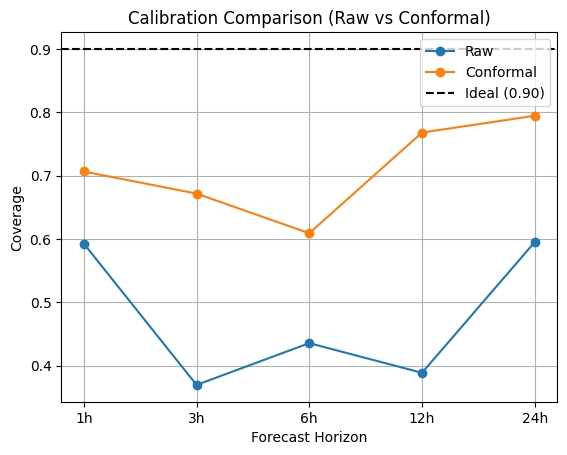

In [ ]:
# =========================
# CALIBRATION COMPARISON PLOT
# =========================

nominal = 0.90  # since using 0.05–0.95 interval

plt.figure()

plt.plot(cov_raw, label="Raw", marker='o')
plt.plot(cov_conf, label="Conformal", marker='o')

plt.axhline(nominal, linestyle='--', color='black', label="Ideal (0.90)")

plt.xticks(range(5), ["1h", "3h", "6h", "12h", "24h"])
plt.xlabel("Forecast Horizon")
plt.ylabel("Coverage")
plt.title("Calibration Comparison (Raw vs Conformal)")
plt.legend()
plt.grid()

plt.show()

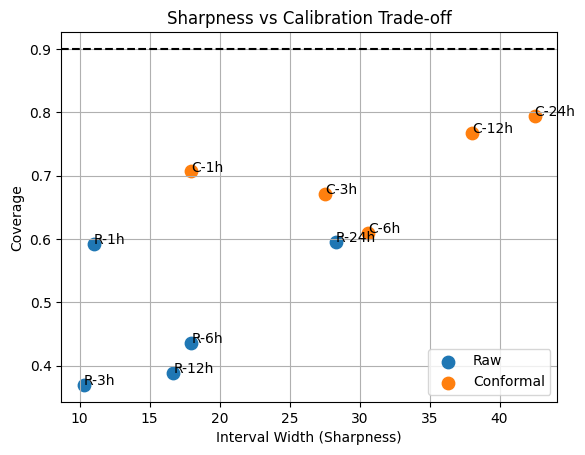

In [ ]:
# =========================
# WIDTH vs COVERAGE (TRADE-OFF)
# =========================

plt.figure()

plt.scatter(width_raw, cov_raw, label="Raw", s=80)
plt.scatter(width_conf, cov_conf, label="Conformal", s=80)

for i, h in enumerate(["1h","3h","6h","12h","24h"]):
    plt.text(width_raw[i], cov_raw[i], f"R-{h}")
    plt.text(width_conf[i], cov_conf[i], f"C-{h}")

plt.axhline(0.90, linestyle='--', color='black')

plt.xlabel("Interval Width (Sharpness)")
plt.ylabel("Coverage")
plt.title("Sharpness vs Calibration Trade-off")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# =========================
# STEP — CRPS (PROPER IMPLEMENTATION)
# =========================

import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

data = np.load(BASE_DIR / "transformer_daynight_conformal_results.npz", allow_pickle=True)

# -------------------------
# LOAD DATA
# -------------------------
y_true = data["y_test_abs"]           # (N, H)
y_pred = data["y_test_pred_abs"]      # (N, H, Q)
quantiles = data["quantiles"]         # (Q,)

print("Shapes:", y_true.shape, y_pred.shape)
print("Quantiles:", quantiles)


# =========================
# CRPS FUNCTION (QUANTILE VERSION)
# =========================
def compute_crps(y_true, y_pred, quantiles):
    """
    Approximate CRPS using quantile forecasts
    """

    N, H, Q = y_pred.shape

    crps_all = np.zeros((N, H))

    for i, q in enumerate(quantiles):

        q_pred = y_pred[:, :, i]

        # Quantile loss
        diff = y_true - q_pred
        loss = np.maximum(q * diff, (q - 1) * diff)

        crps_all += loss

    crps_all /= len(quantiles)

    return crps_all


# =========================
# COMPUTE CRPS
# =========================
crps_matrix = compute_crps(y_true, y_pred, quantiles)

# Mean CRPS per horizon
crps_per_h = crps_matrix.mean(axis=0)

# Global CRPS
crps_mean = crps_matrix.mean()

# -------------------------
# PRINT RESULTS
# -------------------------
horizons = ["1h", "3h", "6h", "12h", "24h"]

print("\n===== CRPS RESULTS =====")

for i, h in enumerate(horizons):
    print(f"{h} → CRPS: {crps_per_h[i]:.3f}")

print("\nOverall CRPS:", round(crps_mean, 3))

Shapes: (4443, 5) (4443, 5, 3)
Quantiles: [0.05 0.5  0.95]

===== CRPS RESULTS =====
1h → CRPS: 2.447
3h → CRPS: 4.227
6h → CRPS: 4.315
12h → CRPS: 4.246
24h → CRPS: 3.994

Overall CRPS: 3.846


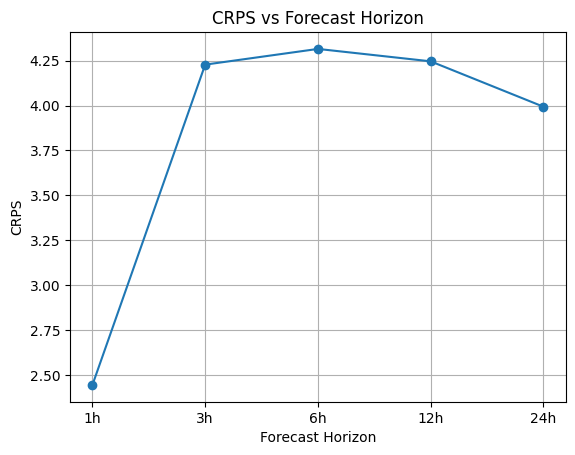

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(horizons, crps_per_h, marker='o')

plt.xlabel("Forecast Horizon")
plt.ylabel("CRPS")
plt.title("CRPS vs Forecast Horizon")
plt.grid()

plt.show()

# **EXPERIMENT 3A — GAUSSIAN NOISE INJECTION**

In [ ]:
# =========================
# NOISE INJECTION EXPERIMENT
# =========================

import numpy as np
from sklearn.metrics import mean_absolute_error

# -------------------------
# FUNCTION: ADD GAUSSIAN NOISE
# -------------------------
def add_gaussian_noise(X, noise_level=0.05):
    """
    noise_level: fraction of std (e.g., 0.05 = 5%)
    """
    X_noisy = X.copy()

    std = np.std(X, axis=(0,1), keepdims=True)
    noise = np.random.randn(*X.shape) * std * noise_level

    return X_noisy + noise


# -------------------------
# FUNCTION: MODEL PREDICTION
# -------------------------
def predict_model(X_input, loader_fn):

    from torch.utils.data import DataLoader, Dataset
    import torch

    class DatasetTS(Dataset):
        def __init__(self, X):
            self.X = torch.tensor(X, dtype=torch.float32)

        def __len__(self):
            return len(self.X)

        def __getitem__(self, i):
            return self.X[i]

    loader = DataLoader(DatasetTS(X_input), batch_size=128, shuffle=False)

    model.train()  # keep dropout ON (MC)

    preds_mc = []

    with torch.no_grad():
        for _ in range(20):
            batch_preds = []

            for xb in loader:
                xb = xb.to(device)
                pred = model(xb).cpu().numpy()
                batch_preds.append(pred)

            batch_preds = np.vstack(batch_preds)
            preds_mc.append(batch_preds)

    preds_mc = np.stack(preds_mc, axis=0)
    mean_preds = preds_mc.mean(axis=0)

    return mean_preds.reshape(-1, HORIZONS, len(quantiles))


# -------------------------
# FUNCTION: EVALUATE MAE
# -------------------------
def evaluate_mae(y_true, y_pred_abs):

    median = y_pred_abs[:, :, 1]

    maes = []
    for i in range(y_true.shape[1]):
        mae = mean_absolute_error(y_true[:, i], median[:, i])
        maes.append(mae)

    return maes


# -------------------------
# BASELINE (NO NOISE)
# -------------------------
y_pred_clean = predict_model(X_test, None)

y_pred_delta = np.zeros_like(y_pred_clean)

for i in range(len(quantiles)):
    y_pred_delta[:, :, i] = y_scaler.inverse_transform(y_pred_clean[:, :, i])

y_pred_abs = p_last_test[:, None, None] + y_pred_delta

mae_clean = evaluate_mae(y_test_true, y_pred_abs)

print("\n===== BASELINE MAE =====")
print(mae_clean)


# -------------------------
# NOISE LEVELS
# -------------------------
noise_levels = [0.01, 0.03, 0.05, 0.1]

results_noise = {}

for nl in noise_levels:

    X_noisy = add_gaussian_noise(X_test, nl)

    y_pred_noisy = predict_model(X_noisy, None)

    y_pred_delta = np.zeros_like(y_pred_noisy)

    for i in range(len(quantiles)):
        y_pred_delta[:, :, i] = y_scaler.inverse_transform(
            y_pred_noisy[:, :, i]
        )

    y_pred_abs = p_last_test[:, None, None] + y_pred_delta

    mae_noisy = evaluate_mae(y_test_true, y_pred_abs)

    results_noise[nl] = mae_noisy

    print(f"\nNoise {nl*100:.0f}% → MAE:", mae_noisy)


===== BASELINE MAE =====
[7.8722710609436035, 11.09601879119873, 12.901015281677246, 12.095669746398926, 13.072265625]

Noise 1% → MAE: [7.860090732574463, 11.138041496276855, 12.899344444274902, 12.102048873901367, 13.11526870727539]

Noise 3% → MAE: [7.86214542388916, 11.13874340057373, 12.883161544799805, 12.117048263549805, 13.10801887512207]

Noise 5% → MAE: [7.837866306304932, 11.126265525817871, 12.893073081970215, 12.13524341583252, 13.12116813659668]

Noise 10% → MAE: [7.847056865692139, 11.140481948852539, 12.912583351135254, 12.089564323425293, 13.131486892700195]


# **EXPERIMENT 3B — MISSING SEGMENT REMOVAL**

In [ ]:
# =========================
# MISSING SEGMENT EXPERIMENT
# =========================

# -------------------------
# FUNCTION: REMOVE RANDOM CHUNKS
# -------------------------
def remove_random_chunks(X, missing_ratio=0.1):

    X_missing = X.copy()

    n_samples, seq_len, n_features = X.shape

    for i in range(n_samples):

        num_missing = int(seq_len * missing_ratio)

        start = np.random.randint(0, seq_len - num_missing)

        X_missing[i, start:start+num_missing, :] = np.nan

    return X_missing


# -------------------------
# SIMPLE IMPUTATION
# -------------------------
def forward_fill(X):

    X_filled = X.copy()

    for i in range(X.shape[0]):
        for j in range(X.shape[2]):

            col = X_filled[i, :, j]

            mask = np.isnan(col)

            if mask.all():
                col[:] = 0
            else:
                valid = np.where(~mask)[0]

                for idx in np.where(mask)[0]:
                    prev = valid[valid < idx]
                    if len(prev) > 0:
                        col[idx] = col[prev[-1]]
                    else:
                        col[idx] = col[valid[0]]

    return X_filled


# -------------------------
# TEST DIFFERENT MISSING LEVELS
# -------------------------
missing_levels = [0.05, 0.1, 0.2]

results_missing = {}

for ml in missing_levels:

    X_missing = remove_random_chunks(X_test, ml)

    X_filled = forward_fill(X_missing)

    y_pred_missing = predict_model(X_filled, None)

    y_pred_delta = np.zeros_like(y_pred_missing)

    for i in range(len(quantiles)):
        y_pred_delta[:, :, i] = y_scaler.inverse_transform(
            y_pred_missing[:, :, i]
        )

    y_pred_abs = p_last_test[:, None, None] + y_pred_delta

    mae_missing = evaluate_mae(y_test_true, y_pred_abs)

    results_missing[ml] = mae_missing

    print(f"\nMissing {ml*100:.0f}% → MAE:", mae_missing)


Missing 5% → MAE: [7.869872570037842, 11.129861831665039, 12.905208587646484, 12.095915794372559, 13.102344512939453]

Missing 10% → MAE: [7.884440898895264, 11.123762130737305, 12.968632698059082, 12.100829124450684, 13.11651611328125]

Missing 20% → MAE: [7.89888858795166, 11.093037605285645, 12.838163375854492, 12.052443504333496, 13.068732261657715]


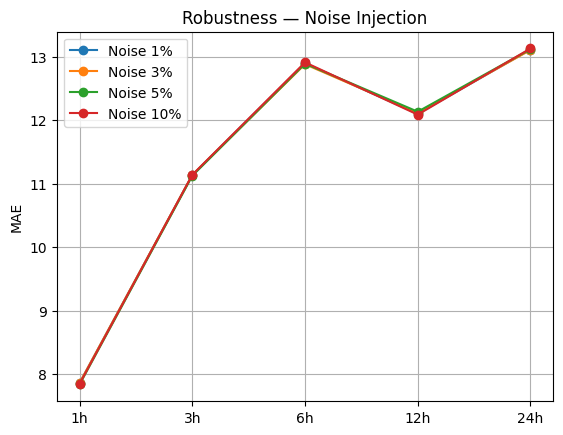

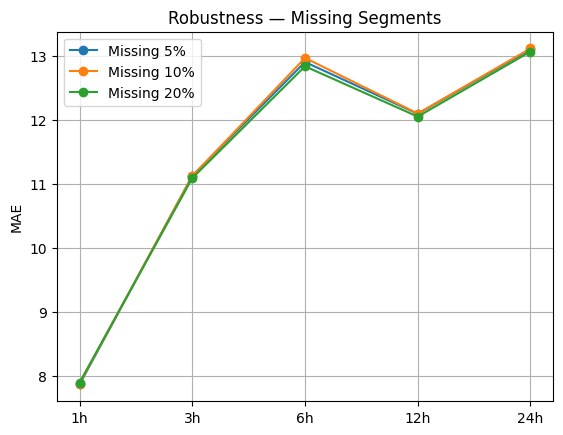

In [ ]:
import matplotlib.pyplot as plt

horizons = ["1h","3h","6h","12h","24h"]

# Noise plot
for nl, mae in results_noise.items():
    plt.plot(horizons, mae, marker='o', label=f"Noise {nl*100:.0f}%")

plt.title("Robustness — Noise Injection")
plt.ylabel("MAE")
plt.legend()
plt.grid()
plt.show()


# Missing plot
for ml, mae in results_missing.items():
    plt.plot(horizons, mae, marker='o', label=f"Missing {ml*100:.0f}%")

plt.title("Robustness — Missing Segments")
plt.ylabel("MAE")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# =========================
# DEBUG — YOUR ACTUAL FILES
# =========================

import pandas as pd
import numpy as np
from pathlib import Path

# -------------------------
# BASE PATH
# -------------------------
BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

DATA_DIR   = BASE_DIR / "data_split_chrono"
WINDOW_DIR = BASE_DIR / "data_windows"

# -------------------------
# 1. CHECK PARQUET FILES
# -------------------------
print("\n===== PARQUET FILE COLUMNS =====")

parquet_files = [
    "train.parquet",
    "val.parquet",
    "test.parquet"
]

for name in parquet_files:
    path = DATA_DIR / name

    print(f"\n{name}")

    if not path.exists():
        print(" File NOT found:", path)
        continue

    df = pd.read_parquet(path)

    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())

# -------------------------
# 2. CHECK NPZ FILE
# -------------------------
print("\n===== NPZ CONTENT =====")

npz_path = WINDOW_DIR / "windows_chrono_multi.npz"

if not npz_path.exists():
    print(" NPZ file NOT found:", npz_path)
else:
    data = np.load(npz_path, allow_pickle=True)

    print("Available keys:")
    for k in data.files:
        print(" -", k)

    print("\n===== NPZ SHAPES =====")
    for k in data.files:
        try:
            print(f"{k}: {data[k].shape}")
        except:
            print(f"{k}: (non-array)")

# -------------------------
# 3. CHECK VARIABLES IN MEMORY
# -------------------------
print("\n===== VARIABLES IN MEMORY =====")

vars_list = list(globals().keys())

useful_vars = [v for v in vars_list if (
    "pred" in v.lower() or
    "y_" in v.lower() or
    "x_" in v.lower()
)]

for v in useful_vars:
    try:
        obj = globals()[v]
        if hasattr(obj, "shape"):
            print(f"{v}: {obj.shape}")
        else:
            print(f"{v}: {type(obj)}")
    except:
        pass


===== PARQUET FILE COLUMNS =====

train.parquet
Shape: (64606, 16)
Columns:
['continuous_time', 'segment_id', 'ps_pressure', 'rhs_local_relative_humidity', 'rhs_humidity_local_temp', 'seconds_in_sol', 'hour_of_sol', 'sin_hour', 'cos_hour', 'is_day', 'ls_deg', 'sin_ls', 'cos_ls', 'ps_pressure_was_missing', 'rhs_local_relative_humidity_was_missing', 'rhs_humidity_local_temp_was_missing']

val.parquet
Shape: (21536, 16)
Columns:
['continuous_time', 'segment_id', 'ps_pressure', 'rhs_local_relative_humidity', 'rhs_humidity_local_temp', 'seconds_in_sol', 'hour_of_sol', 'sin_hour', 'cos_hour', 'is_day', 'ls_deg', 'sin_ls', 'cos_ls', 'ps_pressure_was_missing', 'rhs_local_relative_humidity_was_missing', 'rhs_humidity_local_temp_was_missing']

test.parquet
Shape: (21536, 16)
Columns:
['continuous_time', 'segment_id', 'ps_pressure', 'rhs_local_relative_humidity', 'rhs_humidity_local_temp', 'seconds_in_sol', 'hour_of_sol', 'sin_hour', 'cos_hour', 'is_day', 'ls_deg', 'sin_ls', 'cos_ls', 'ps_pressu

# **Mars Forecasting using DL**

In [ ]:
# =========================
# BLOCK 1 — SETUP
# =========================

import numpy as np
import torch
from pathlib import Path
import joblib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

DATA_PATH = BASE_DIR / "New_data_scaled" / "scaled_chrono.npz"
Y_SCALER_PATH = BASE_DIR / "New_data_scaled" / "y_scaler.pkl"

LSTM_MODEL_PATH = BASE_DIR / "models" / "lstm_model.pth"
TRANS_MODEL_PATH = BASE_DIR / "models" / "transformer_model.pth"

In [ ]:
# =========================
# BLOCK 2 — LOAD DATA
# =========================

data = np.load(DATA_PATH, allow_pickle=True)

X_test = data["X_test"]
y_test_true = data["y_test_true"]
p_last_test = data["p_last_test"]

y_scaler = joblib.load(Y_SCALER_PATH)

print("X_test shape:", X_test.shape)

X_test shape: (4443, 360, 9)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# =========================
# BLOCK 3 — MODEL DEFINITIONS
# =========================

import torch.nn as nn

# ----- LSTM -----
class StrongLSTM(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=3,
            batch_first=True,
            dropout=0.1
        )

        self.head = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_size)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.head(out)


# ----- Transformer -----
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, 64)
        self.pos_enc = PositionalEncoding(64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            dropout=0.2,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.head = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        return self.head(x)

In [ ]:
# =========================
# BLOCK 4 — LOAD MODELS
# =========================

# ----- LSTM -----
ckpt_lstm = torch.load(LSTM_MODEL_PATH)

lstm_model = StrongLSTM(
    input_size=ckpt_lstm["input_size"],
    output_size=ckpt_lstm["output_size"]
).to(device)

lstm_model.load_state_dict(ckpt_lstm["model_state_dict"])
lstm_model.eval()

# ----- Transformer -----
ckpt_trans = torch.load(TRANS_MODEL_PATH)

trans_model = TimeSeriesTransformer(
    input_dim=ckpt_trans["input_dim"],
    output_dim=ckpt_trans["output_dim"]
).to(device)

trans_model.load_state_dict(ckpt_trans["model_state_dict"])
trans_model.eval()

print("Models loaded successfully")

Models loaded successfully


In [ ]:
# =========================
# SINGLE FUTURE FORECAST (CORRECTED)
# =========================

# ---- 1. Take latest window ----
X_latest = X_test[-1:]   # (1, lookback, features)

# ---- 2. Convert to tensor ----
X_t = torch.tensor(X_latest, dtype=torch.float32).to(device)

# ---- 3. Predict (scaled delta) ----
with torch.no_grad():
    pred_lstm_scaled = lstm_model(X_t).cpu().numpy()

with torch.no_grad():
    pred_trans_scaled = trans_model(X_t).cpu().numpy()

# ---- 4. Inverse scale (delta → Pa) ----
pred_lstm_delta = y_scaler.inverse_transform(pred_lstm_scaled)
pred_trans_delta = y_scaler.inverse_transform(pred_trans_scaled)

# ---- 5. Use REAL last pressure (IMPORTANT FIX) ----
p_last_real = p_last_test[-1]   # already in Pa

# ---- 6. Convert to absolute pressure ----
pred_lstm_abs = p_last_real + pred_lstm_delta
pred_trans_abs = p_last_real + pred_trans_delta

# ---- 7. Print results ----
labels = ["1h", "3h", "6h", "12h", "24h"]

print("\n===== FUTURE FORECAST (ABSOLUTE PRESSURE) =====")
print("Last observed pressure (Pa):", p_last_real)

print("\n--- LSTM Forecast ---")
for i, h in enumerate(labels):
    print(f"{h}: {pred_lstm_abs[0, i]:.2f} Pa")

print("\n--- Transformer Forecast ---")
for i, h in enumerate(labels):
    print(f"{h}: {pred_trans_abs[0, i]:.2f} Pa")


===== FUTURE FORECAST (ABSOLUTE PRESSURE) =====
Last observed pressure (Pa): 737.8416

--- LSTM Forecast ---
1h: 745.20 Pa
3h: 740.68 Pa
6h: 735.54 Pa
12h: 736.44 Pa
24h: 732.96 Pa

--- Transformer Forecast ---
1h: 734.17 Pa
3h: 730.41 Pa
6h: 737.87 Pa
12h: 740.56 Pa
24h: 738.52 Pa


 Plot saved to: /content/drive/MyDrive/NASA_MEDA/results/future_forecast_comparison.png


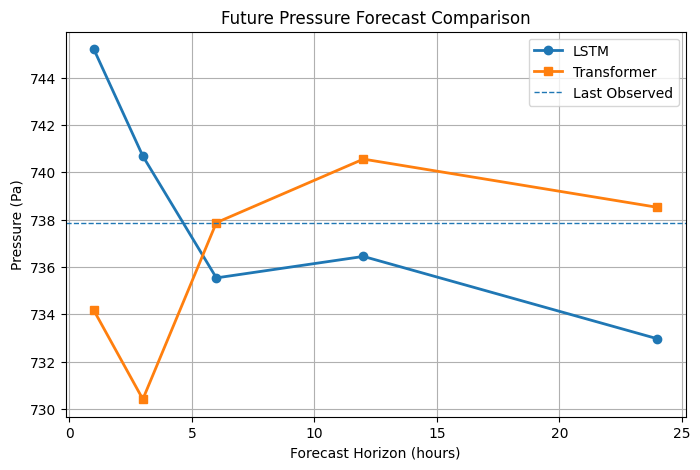

In [ ]:
# =========================
# FUTURE FORECAST COMPARISON PLOT
# =========================

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# -------------------------
# HORIZONS (in hours)
# -------------------------
horizons = [1, 3, 6, 12, 24]

# -------------------------
# USE YOUR PREDICTIONS
# -------------------------
lstm_vals = pred_lstm_abs.flatten()
trans_vals = pred_trans_abs.flatten()

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(8,5))

plt.plot(horizons, lstm_vals, marker='o', linewidth=2, label="LSTM")
plt.plot(horizons, trans_vals, marker='s', linewidth=2, label="Transformer")

# Last observed point (anchor)
plt.axhline(y=p_last_real, linestyle='--', linewidth=1, label="Last Observed")

# Labels
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Pressure (Pa)")
plt.title("Future Pressure Forecast Comparison")

plt.legend()
plt.grid()

# -------------------------
# SAVE
# -------------------------
SAVE_PATH = Path("/content/drive/MyDrive/NASA_MEDA/results")
SAVE_PATH.mkdir(exist_ok=True)

plot_path = SAVE_PATH / "future_forecast_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

print(" Plot saved to:", plot_path)

plt.show()

# **FINAL COMPARISON TABLE**

In [ ]:
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA/New_data_scaled")
BASELINE_PATH = BASE_DIR / "baseline_predictions.npz"

data = np.load(BASELINE_PATH)

print("Available keys:")
print(data.files)

Available keys:
['y_test_true', 'y_pred_persist', 'y_pred_rf', 'p_last_test', 'horizons', 'indices']


In [ ]:
# =========================
# FINAL MODEL COMPARISON (FULL METRICS)
# =========================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BASE_DIR = Path("/content/drive/MyDrive/NASA_MEDA")

# -------------------------
# PATHS
# -------------------------
BASELINE_PATH = BASE_DIR / "New_data_scaled" / "baseline_predictions.npz"
LSTM_PATH     = BASE_DIR / "results" / "lstm_results.csv"
TRANS_PATH    = BASE_DIR / "transformer_results.npz"

labels = ["1h", "3h", "6h", "12h", "24h"]

# -------------------------
# METRIC FUNCTION
# -------------------------
def compute_all_metrics(y_true, y_pred):
    results = []

    for i, h in enumerate(labels):
        y_t = y_true[:, i]
        y_p = y_pred[:, i]

        mae = mean_absolute_error(y_t, y_p)
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        r2 = r2_score(y_t, y_p)
        mape = np.mean(np.abs((y_t - y_p) / np.maximum(y_t, 1e-6))) * 100

        results.append((mae, rmse, r2, mape))

    return results

# -------------------------
# LOAD BASELINES
# -------------------------
baseline_data = np.load(BASELINE_PATH)

y_true = baseline_data["y_test_true"]

y_pred_persist = baseline_data["y_pred_persist"]
y_pred_rf      = baseline_data["y_pred_rf"]

persist_metrics = compute_all_metrics(y_true, y_pred_persist)
rf_metrics      = compute_all_metrics(y_true, y_pred_rf)

# -------------------------
# LOAD LSTM
# -------------------------
lstm_df = pd.read_csv(LSTM_PATH)

lstm_metrics = []
for i in range(len(labels)):
    mae  = lstm_df["MAE"][i]
    rmse = lstm_df["RMSE"][i]
    r2   = lstm_df["R2"][i]
    mape = lstm_df["MAPE (%)"][i]
    lstm_metrics.append((mae, rmse, r2, mape))

# -------------------------
# LOAD TRANSFORMER
# -------------------------
trans_data = np.load(TRANS_PATH)

y_pred_trans = trans_data["y_pred_abs"]
y_true_trans = trans_data["y_test_abs"]

trans_metrics = compute_all_metrics(y_true_trans, y_pred_trans)

# -------------------------
# BUILD TABLE
# -------------------------
rows = []

def build_row(model_name, metrics):
    row = {"Model": model_name}
    for i, h in enumerate(labels):
        mae, rmse, r2, mape = metrics[i]

        row[f"{h}_MAE"]  = round(mae, 3)
        row[f"{h}_RMSE"] = round(rmse, 3)
        row[f"{h}_R2"]   = round(r2, 3)
        row[f"{h}_MAPE"] = round(mape, 3)

    return row

rows.append(build_row("Persistence", persist_metrics))
rows.append(build_row("Random Forest", rf_metrics))
rows.append(build_row("LSTM", lstm_metrics))
rows.append(build_row("Transformer", trans_metrics))

df_final = pd.DataFrame(rows)

# -------------------------
# PRINT
# -------------------------
print("\n===== FINAL MODEL COMPARISON (FULL) =====")
print(df_final)

# -------------------------
# SAVE
# -------------------------
SAVE_PATH = BASE_DIR / "results"
SAVE_PATH.mkdir(exist_ok=True)

csv_path = SAVE_PATH / "final_model_comparison_full.csv"
df_final.to_csv(csv_path, index=False)

print("\nSaved to:", csv_path)


===== FINAL MODEL COMPARISON (FULL) =====
           Model  1h_MAE  1h_RMSE  1h_R2  1h_MAPE  3h_MAE  3h_RMSE  3h_R2  \
0    Persistence   6.606    9.113  0.547    0.914  13.910   17.171 -0.668   
1  Random Forest   5.408    7.539  0.690    0.748   9.236   12.911  0.057   
2           LSTM   6.612    9.609  0.496    0.912  14.465   18.187 -0.871   
3    Transformer   6.343    9.124  0.546    0.874  12.788   16.387 -0.519   

   3h_MAPE  6h_MAE  ...  6h_R2  6h_MAPE  12h_MAE  12h_RMSE  12h_R2  12h_MAPE  \
0    1.933  17.636  ... -1.707    2.450   15.966    19.140  -1.058     2.212   
1    1.277  12.237  ... -0.454    1.704   11.840    15.198  -0.298     1.648   
2    2.000  20.213  ... -2.295    2.788   15.417    18.475  -0.917     2.130   
3    1.762  12.417  ... -0.349    1.722   13.345    16.935  -0.611     1.861   

   24h_MAE  24h_RMSE  24h_R2  24h_MAPE  
0   15.085    19.025  -1.681     2.072  
1   12.546    16.012  -0.899     1.720  
2   17.586    22.303  -2.685     2.405  
3   12